# 🚗 AI System for Car Price Prediction

Business Scenario  
A used car marketplace company wants to build an AI-based price recommendation system.  
Currently, dealers manually estimate the price of cars based on experience. This often leads to:  
Incorrect pricing  
Loss of potential buyers  
Inconsistent valuations  

To solve this, the company wants to build an AI model that predicts the price of a car automatically based on its features.

Build a Feed Forward Neural Network model that predicts the price of a car using the provided dataset.

# Task 1 — Data Understanding

Load the dataset and analyze it.  
Students must:  
Load dataset using pandas  
Display first 5 rows  
Check dataset information  
Check missing values  
Show statistical summary  

In [3]:
import numpy as np
import pandas as pd
df=pd.read_csv("CarPrice_dataset.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
df.isna().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [5]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


# Task 2 — Data Cleaning

Students must:  
Handle missing values  
Remove duplicates  
Fix inconsistent data types  

In [6]:
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [9]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
df.dtypes

car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

In [11]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

# Task 3 — Data Preprocessing
Students must prepare data for neural network.  
Required steps:  
Encode categorical variables  
Example:  
Fuel Type → Petrol / Diesel → One Hot Encoding   
Transmission → Manual / Automatic  
Normalize numerical features  
Example:  
MinMaxScaler  
or  
StandardScaler  
Split dataset  
Train → 80%  
Test → 20%  

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

X=df.drop(columns='price')
y=df['price']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object' ]).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

#Define Preprocessing steps
preprocessor = ColumnTransformer(
transformers=[
('num', StandardScaler(), numerical_cols),
('car', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])
#Apply Preprocessing
X_processed=preprocessor.fit_transform(X)

#Split the data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

In [13]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


# Task 4 — Build Feed Forward Neural Network

must design an FNN model.  
Architecture example:  
Input Layer → Hidden Layer → Hidden Layer → Output Layer  
Example configuration:  
Input Layer: Number of features  
Hidden Layer 1: 64 neurons (ReLU)  
Hidden Layer 2: 32 neurons (ReLU)  
Output Layer: 1 neuron (Price)  

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [15]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)), 
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)   # Output Layer (Price prediction)
])
model.summary()

c:\Users\spoor\anaconda3\envs\myenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       102,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277,505 (1.06 MB)

 Trainable params: 277,505 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

# Task 5 — Train the Model

You must train the neural network.  
Example configuration:  
Loss Function → Mean Squared Error  
Optimizer → Adam  
Epochs → 50  
Batch Size → 32  
You must visualize:  
Training Loss vs Epochs  

In [16]:
model.compile(
    optimizer='adam',
    loss='mean_absolute_error',
    metrics=['mean_absolute_error','mean_squared_error']
)

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=70,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 12754.3516 - mean_absolute_error: 12754.3516 - mean_squared_error: 213457808.0000 - val_loss: 15080.7178 - val_mean_absolute_error: 15080.7178 - val_mean_squared_error: 317865440.0000
Epoch 2/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 12751.0107 - mean_absolute_error: 12751.0107 - mean_squared_error: 213365568.0000 - val_loss: 15073.2969 - val_mean_absolute_error: 15073.2969 - val_mean_squared_error: 317616960.0000
Epoch 3/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 12740.3359 - mean_absolute_error: 12740.3359 - mean_squared_error: 213089552.0000 - val_loss: 15051.3223 - val_mean_absolute_error: 15051.3223 - val_mean_squared_error: 316887936.0000
Epoch 4/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 12709.8467 - mean_absolute_error: 12709.8467 - mean_squared_error: 212264912.0000 - val_loss: 14993.0859 - val_mean_absolute_error: 14993.0859 - val_mean_squared_error: 314979296.0000
Epoch 5/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 

In [18]:
import matplotlib.pyplot as plt

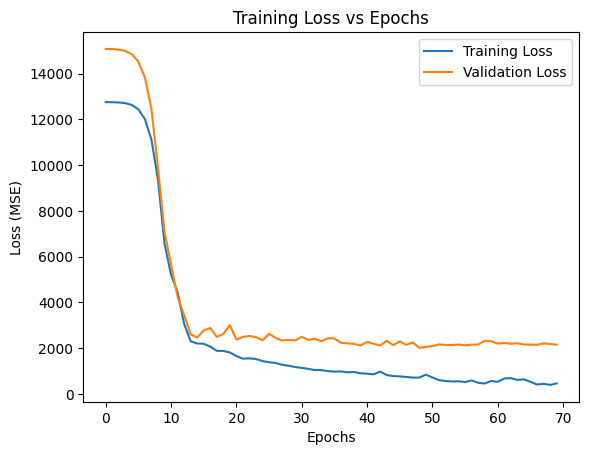

In [19]:
plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss vs Epochs")
plt.legend()

plt.show()

# Task 6 — Model Evaluation

Evaluate the model using regression metrics.  
Students must compute:  
Mean Absolute Error (MAE)  
Mean Squared Error (MSE)  
Root Mean Squared Error (RMSE)  
R² Score  
Students must interpret:  
Is the model accurate?
 

In [20]:
from sklearn.metrics import *

In [21]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


In [22]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1851.7366971227134
Mean Squared Error (MSE): 8683973.08507277
Root Mean Squared Error (RMSE): 2946.858171862496
R² Score: 0.8899983432778193


# Task 7 — Prediction

must test the model with new car data.  


In [23]:
new_data=X.iloc[[0]]
new_data_precessed=preprocessor.transform(new_data)
predicted_price=model.predict(new_data_precessed)
print(f'Predicted price:{predicted_price[0][0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted price:13544.2880859375


In [26]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(X.columns, "features.pkl")

['features.pkl']

In [27]:
model.save("car_price_model.keras")